In [88]:
import os

def list_subdirectories(parent_dir):
    return [
        name for name in os.listdir(parent_dir)
        if os.path.isdir(os.path.join(parent_dir, name)) and 'logs' not in name
    ]



In [89]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_comparison_png(parent_dir, subdirectory):
    comparison_path = os.path.join(parent_dir, subdirectory, "comparison.png")
    img = mpimg.imread(comparison_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{subdirectory}/comparison.png")
    plt.show()


In [183]:
flux_results_path = '/data3/jhpark/artifact_100'
flux_results_dirs = list_subdirectories(flux_results_path)

flux_results_iter = iter(flux_results_dirs)

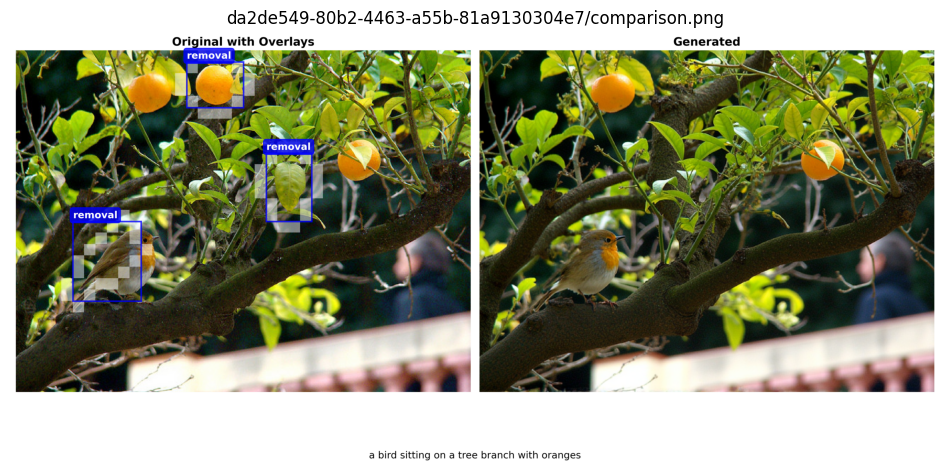

In [ ]:
flux_result = next(flux_results_iter)
import pickle

# metadata_path = os.path.join(flux_results_path, flux_result, "metadata.pkl")
# with open(metadata_path, "rb") as f:
#     metadata = pickle.load(f)

# if any(artifact.get('artifact_type') == 'fusion' for artifact in metadata.get('artifacts', [])):
#     plot_comparison_png(flux_results_path, flux_result)

plot_comparison_png(flux_results_path, flux_result)

In [ ]:
import pickle
metadata_path = os.path.join(flux_results_path, flux_result, "metadata.pkl")
with open(metadata_path, "rb") as f:
    metadata = pickle.load(f)
    # print(metadata)
    # print(metadata['artifacts'])
for i, artifact in enumerate(metadata['artifacts']):
    # Load the original image
    import numpy as np
    from PIL import Image

    original_image_path = os.path.join(flux_results_path, flux_result, "real_image.png")
    artifact_image_path = os.path.join(flux_results_path, flux_result, "artifact.png")
    original_img = mpimg.imread(original_image_path)
    artifact_img = mpimg.imread(artifact_image_path)
    if artifact['artifact_type'] == 'fusion':
        print(artifact['entity'], artifact['fused_entity'])
    else:
        print(artifact['entity'], artifact['subentity'])

    patch_indices = artifact.get('target_patch_indices', None)
    if patch_indices is None:
        print(f"Artifact {i}: No target_patch_indices found.")
        continue

    patch_size = artifact.get('patch_size', 16)
    grid_shape = artifact.get('patch_grid_shape', None)
    img_h, img_w = original_img.shape[:2]

    if grid_shape is None:
        grid_rows = img_h // patch_size
        grid_cols = img_w // patch_size
    else:
        grid_rows, grid_cols = grid_shape

    patch_coords = []
    for idx in patch_indices:
        idx -= 512
        if isinstance(idx, (list, tuple)) and len(idx) == 2:
            row, col = idx
        else:
            row = idx // grid_cols
            col = idx % grid_cols
        patch_coords.append((row, col))

    # Create a mask for the target region
    mask = np.zeros((img_h, img_w), dtype=bool)
    for row, col in patch_coords:
        y_start = row * patch_size
        x_start = col * patch_size
        y_end = min(y_start + patch_size, img_h)
        x_end = min(x_start + patch_size, img_w)
        mask[y_start:y_end, x_start:x_end] = True

    # Prepare the three images
    # 1. Original image with target region masked out
    original_masked = original_img.copy()
    if original_masked.dtype == np.uint8:
        fill_value = 0
    else:
        fill_value = 0.0
    original_masked[mask] = fill_value if np.isscalar(fill_value) else np.array(fill_value)
    # 2. Original image with only target region visible
    original_only_target = np.zeros_like(original_img)
    original_only_target[mask] = original_img[mask]
    # 3. Artifact image with only target region visible
    artifact_only_target = np.zeros_like(artifact_img)
    artifact_only_target[mask] = artifact_img[mask]

    # Show the three images using PIL.Image
    def to_pil(img):
        arr = img
        if arr.dtype in (np.float32, np.float64):
            if arr.max() <= 1.0:
                arr = (arr * 255).clip(0, 255)
            arr = arr.astype(np.uint8)
        if arr.ndim == 2:
            return Image.fromarray(arr)
        elif arr.shape[2] == 1:
            return Image.fromarray(arr[:, :, 0])
        elif arr.shape[2] == 3:
            return Image.fromarray(arr)
        elif arr.shape[2] == 4:
            return Image.fromarray(arr[:, :, :3])
        else:
            raise ValueError(f"Unexpected image shape: {arr.shape}")

    from IPython.display import display

    print(f"Artifact {i}: Original w/ Target Masked Out")
    display(to_pil(original_masked))
    print(f"Artifact {i}: Original Only Target Region")
    display(to_pil(original_only_target))
    print(f"Artifact {i}: Artifact Only Target Region")
    display(to_pil(artifact_only_target))

    # Save all three images
    to_pil(original_masked).save(f"examples/original_masked_{i}.png")
    to_pil(original_only_target).save(f"examples/original_target_{i}.png")
    to_pil(artifact_only_target).save(f"examples/artifact_target_{i}.png")


FileNotFoundError: [Errno 2] No such file or directory: '/data3/jhpark/artifacts_100/da2de549-80b2-4463-a55b-81a9130304e7/artifact.png'